# The model steers the limit point, and the radius rule does not

`SPDTarget(target = x^*)` builds a model Hessian that is positive definite and
whose unconstrained model minimiser is pinned to `x^*`. Pointed at the saddle
$(0.75, 0)$, it produces a run in which every hypothesis of the first-order
theory holds, every ratio is successful, $\|g_k\| \to 0$, and the limit is
nonetheless a saddle.

The failure is the model. No radius rule repairs it, which is the claim this
notebook tests by running every radius rule the package exposes against the same
model and the same starting point.

The construction exists at $x$ exactly when $\varphi(x) = g(x)^{\!\top}(x^* - x)
< 0$, so the target must lie downhill. Where it does not, `SPDTarget` raises a
`DomainError`, and a run that raises is reported here as an outcome rather than
dropped.

In [1]:
const SADDLEDIR = @__DIR__
using Pkg; Pkg.activate(joinpath(SADDLEDIR, "..", ".."))
include(joinpath(SADDLEDIR, "..", "saddle_problem.jl"))

# Every radius rule the package exports, at the shared constants of
# `saddle_problem.jl`. Nothing is tuned per rule.
const ALL_RULES = [
    ("RDelta",              () -> RDelta(γ1 = G1, γ2 = G2, γ3 = G3, Δmin = 0.0)),
    ("RStep",               () -> RStep(γ1 = G1, γ2 = G2, γ3 = G3, Δmin = 0.0)),
    ("RDeltaStep",          () -> RDeltaStep(γ1 = G1, γ2 = G2, γ3 = G3, Δmin = 0.0)),
    ("RDFO",                () -> RDFO(γ1 = G1, γ2 = G2, γ3 = G3, ζ = ZETA, Δmin = 0.0)),
    ("RGrad",               () -> RGrad(γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0, Δmin = 0.0)),
    ("RGradCapped",         () -> RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0,
                                              μ_max = MU_BAR, Δmin = 0.0)),
    ("RAdaptiveStep",       () -> RAdaptiveStep(λ1 = 5.0, λ2 = 5.0, Δmin = 0.0)),
    ("RAdaptiveGrad",       () -> RAdaptiveGrad(μ = MU0, λ1 = 5.0, λ2 = 5.0, Δmin = 0.0)),
    ("RAdaptiveGradCapped", () -> RAdaptiveGradCapped(μ = MU0, μ_max = MU_BAR,
                                                      λ1 = 5.0, λ2 = 5.0, Δmin = 0.0)),
    ("RRTR",                () -> RRTR(γ1 = G1, γ2 = G2, γ3 = G3, Δmin = 0.0)),
    ("RRTRGrad",            () -> RRTRGrad(γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0, Δmin = 0.0)),
]

@printf("%d radius rules, one model, one starting point x0 = (%.2f, %.2f)\n",
        length(ALL_RULES), X0_DEFAULT[1], X0_DEFAULT[2])
@printf("phi(x0) = g(x0)'(saddle - x0) = %+.6f, so the construction exists at x0: %s\n",
        dot(grad(X0_DEFAULT), SADDLE .- X0_DEFAULT),
        dot(grad(X0_DEFAULT), SADDLE .- X0_DEFAULT) < 0 ? "yes" : "no")

  Activating project at `c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks`


11 radius rules, one model, one starting point x0 = (-0.50, 0.60)
phi(x0) = g(x0)'(saddle - x0) = -2.277100, so the construction exists at x0: yes


## 1. Every rule, the same model

The limit is verified three ways and not by the classifier alone. The distance to
$(0.75, 0)$, the gradient norm at the returned point, and $\lambda_{\min}$ of
$\nabla^2 f$ there, which at the saddle is $-1/4$ exactly. The last column is the
deviation of that eigenvalue from $-1/4$.

A run that raised is a row with its rule named, not a gap in the table.

In [2]:
"""
    spd_row(name, mkrule; tol_H, model) -> NamedTuple

One run, with the three independent checks on the returned point. Errors are
caught and reported as the outcome, with the rule named.
"""
function spd_row(name, mkrule; tol_H = -1.0, mkmodel = () -> SPDTarget(target = SADDLE),
                  subsolver = () -> SteihaugCG())
    try
        st = run_cfg(rule = mkrule(), model = mkmodel(), subsolver = subsolver(),
                     tol_H = tol_H)
        x  = st.solution
        nc = nearest_crit(x)
        λ  = eigvals(Symmetric(hess(x)))[1]
        λm = get(st.solver_specific, :lambda_min_trajectory, Float64[])
        return (rule = name, ok = true, status = st.status, iter = st.iter,
                limit = nc.name, dist = nc.dist,
                dist_saddle = norm(x .- SADDLE),
                gnorm = Float64(st.dual_feas),
                lam_true = λ, lam_dev = abs(λ - (-0.25)),
                lam_model = isempty(λm) ? NaN : λm[end],
                obj = Float64(st.objective),
                tail = active_fraction(st; tail = 0.1), st = st)
    catch err
        err isa InterruptException && rethrow()
        return (rule = name, ok = false, status = Symbol(nameof(typeof(err))),
                iter = 0, limit = "n/a", dist = NaN, dist_saddle = NaN,
                gnorm = NaN, lam_true = NaN, lam_dev = NaN, lam_model = NaN,
                obj = NaN, tail = NaN, st = nothing)
    end
end

function spd_table(rows; title = "")
    isempty(title) || (println("\n", "="^124); println(title); println("="^124))
    @printf("%-22s %13s %6s | %-8s %11s %11s %11s | %12s %11s %9s\n",
            "rule", "status", "iter", "limit", "dist", "dist saddle", "|g|",
            "lam true", "|lam+0.25|", "tail act")
    println("-"^124)
    for r in rows
        if !r.ok
            @printf("%-22s %13s %6s | %-8s %11s %11s %11s | %12s %11s %9s\n",
                    r.rule, string(r.status), "n/a", "n/a", "n/a", "n/a", "n/a",
                    "n/a", "n/a", "n/a")
        else
            @printf("%-22s %13s %6d | %-8s %11.3e %11.3e %11.3e | %12.8f %11.2e %9.4f\n",
                    r.rule, string(r.status), r.iter, r.limit, r.dist,
                    r.dist_saddle, r.gnorm, r.lam_true, r.lam_dev, r.tail)
        end
    end
end

SPD_OFF = [spd_row(nm, mk) for (nm, mk) in ALL_RULES]
spd_table(SPD_OFF;
          title = "TABLE 1. SPDTarget(target = saddle), second-order test OFF, truncated CG.")

let ok  = [r for r in SPD_OFF if r.ok],
    bad = [r for r in SPD_OFF if !r.ok],
    sad = [r for r in SPD_OFF if r.ok && r.limit == "saddle"]
    println()
    @printf("rules run                       : %d\n", length(SPD_OFF))
    @printf("rules that raised               : %d  %s\n", length(bad), [r.rule for r in bad])
    @printf("rules whose limit is the saddle : %d of %d that ran\n", length(sad), length(ok))
    if !isempty(ok)
        @printf("worst distance to the saddle    : %.3e\n", maximum(r.dist_saddle for r in ok))
        @printf("worst |lambda_min + 1/4|        : %.3e\n", maximum(r.lam_dev for r in ok))
        @printf("worst |g| at the returned point : %.3e\n", maximum(r.gnorm for r in ok))
    end
    println()
    if !isempty(ok) && length(sad) == length(ok)
        println("VERDICT: every rule that ran reached the saddle. The model chose the",
                "\n         limit point and the radius rule did not.")
    else
        println("VERDICT: the rules do not agree on the limit. The model is not the only",
                "\n         thing deciding it.")
    end
end


TABLE 1. SPDTarget(target = saddle), second-order test OFF, truncated CG.
rule                          status   iter | limit           dist dist saddle         |g| |     lam true  |lam+0.25|  tail act
----------------------------------------------------------------------------------------------------------------------------
RDelta                   first_order      2 | saddle     2.776e-17   2.776e-17   6.939e-18 |  -0.25000000    0.00e+00    0.0000
RStep                    first_order      2 | saddle     2.776e-17   2.776e-17   6.939e-18 |  -0.25000000    0.00e+00    0.0000
RDeltaStep               first_order      2 | saddle     2.776e-17   2.776e-17   6.939e-18 |  -0.25000000    0.00e+00    0.0000
RDFO                     first_order      2 | saddle     2.776e-17   2.776e-17   6.939e-18 |  -0.25000000    0.00e+00    0.0000
RGrad                    first_order      5 | saddle     6.939e-17   6.939e-17   1.735e-17 |  -0.25000000    0.00e+00    0.0000
RGradCapped              first_o

In [3]:
const MU_SWEEP   = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 4.0, 8.0, 128.0]
const ZETA_SWEEP = [0.1, 0.5, 1.0, 2.0, 5.0, 20.0]

6-element Vector{Float64}:
  0.1
  0.5
  1.0
  2.0
  5.0
 20.0

In [4]:
mk_cap(μm) = RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3, μ = min(MU0, μm), μ_max = μm)
mk_dfo(ζ)  = RDFO(γ1 = G1, γ2 = G2, γ3 = G3, ζ = ζ)

"""
    sweep_row(rule, subsolver) -> NamedTuple

One `tr_solve`, reduced to the columns of the table. Every entry is read from
`stats.solver_specific` or from a diagnostic of `saddle_problem.jl`. Nothing is
recomputed from the iterates.
"""
function sweep_row(rule; subsolver = SteihaugCG(), model = SPDTarget(target = SADDLE),
                   tol_H = -1.0, x0 = X0_DEFAULT)
    st, xs = solve_path(rule = rule, model = model, subsolver = subsolver,
                        tol_H = tol_H, x0 = x0, kmax = KMAX, tol = TOL)
    ss = st.solver_specific
    cosc = ss[:cos_cauchy_trajectory]
    Δ    = ss[:delta_trajectory]
    tr, ins, kry = step_classes(ss)
    nc = nearest_crit(st.solution)
    fin = filter(isfinite, cosc)
    return (st = st, xs = xs, status = st.status, iter = st.iter,
            cauchy   = hypotheses_report(st).cauchy_fraction,
            cos_last = isempty(fin) ? NaN : fin[end],
            cos_min  = isempty(fin) ? NaN : minimum(fin),
            cos_frac = isempty(cosc) ? NaN :
                       count(x -> isfinite(x) && x > 1 - 1e-12, cosc) / length(cosc),
            trunc = tr, inside = ins, krylov = kry,
            tail  = active_fraction(st; tail = 0.1),
            limit = nc.name, dist = nc.dist,
            gnorm = Float64(st.dual_feas),
            delta_end = Δ[end], delta_min = minimum(Δ))
end

function sweep_table(rows, params, pname; title = "")
    isempty(title) || (println("\n", "="^128); println(title); println("="^128))
    @printf("%8s %10s %6s | %8s %8s | %9s %9s %9s | %8s %8s %8s | %8s | %-7s %9s %9s\n",
            pname, "status", "iter", "cauchy", "cos last",
            "cos min", "cos frac", "tail act", "trunc", "inside", "krylov",
            "Delta end", "limit", "dist", "|g|")
    println("-"^128)
    for (p, r) in zip(params, rows)
        @printf("%8.2f %10s %6d | %8.4f %8.5f | %9.6f %9.4f %9.4f | %8.4f %8.4f %8.4f | %8.2e | %-7s %9.2e %9.2e\n",
                p, string(r.status), r.iter, r.cauchy, r.cos_last,
                r.cos_min, r.cos_frac, r.tail, r.trunc, r.inside, r.krylov,
                r.delta_end, r.limit, r.dist, r.gnorm)
    end
end

CAP_CG = [sweep_row(mk_cap(μm)) for μm in MU_SWEEP]
sweep_table(CAP_CG, MU_SWEEP, "mu_max";
            title = "TABLE 1. R-grad capped, exact Hessian, truncated CG.")




TABLE 1. R-grad capped, exact Hessian, truncated CG.
  mu_max     status   iter |   cauchy cos last |   cos min  cos frac  tail act |    trunc   inside   krylov | Delta end | limit        dist       |g|
--------------------------------------------------------------------------------------------------------------------------------
    0.01   max_iter   2000 |   1.0000  1.00000 |  1.000000    1.0000    1.0000 |   1.0000   0.0000   0.0000 | 6.17e-06 | origin   1.42e-02  6.17e-04
    0.05   max_iter   2000 |   1.0000  1.00000 |  1.000000    1.0000    1.0000 |   1.0000   0.0000   0.0000 | 1.53e-06 | origin   3.19e-03  3.07e-05
    0.10   max_iter   2000 |   1.0000  1.00000 |  1.000000    1.0000    1.0000 |   1.0000   0.0000   0.0000 | 7.93e-07 | origin   1.62e-03  7.93e-06
    0.30   max_iter   2000 |   1.0000  1.00000 |  1.000000    1.0000    1.0000 |   1.0000   0.0000   0.0000 | 2.29e-07 | origin   5.05e-04  7.65e-07
    0.50  exception      7 |   0.8571  0.82367 |  0.823669    0.8571   

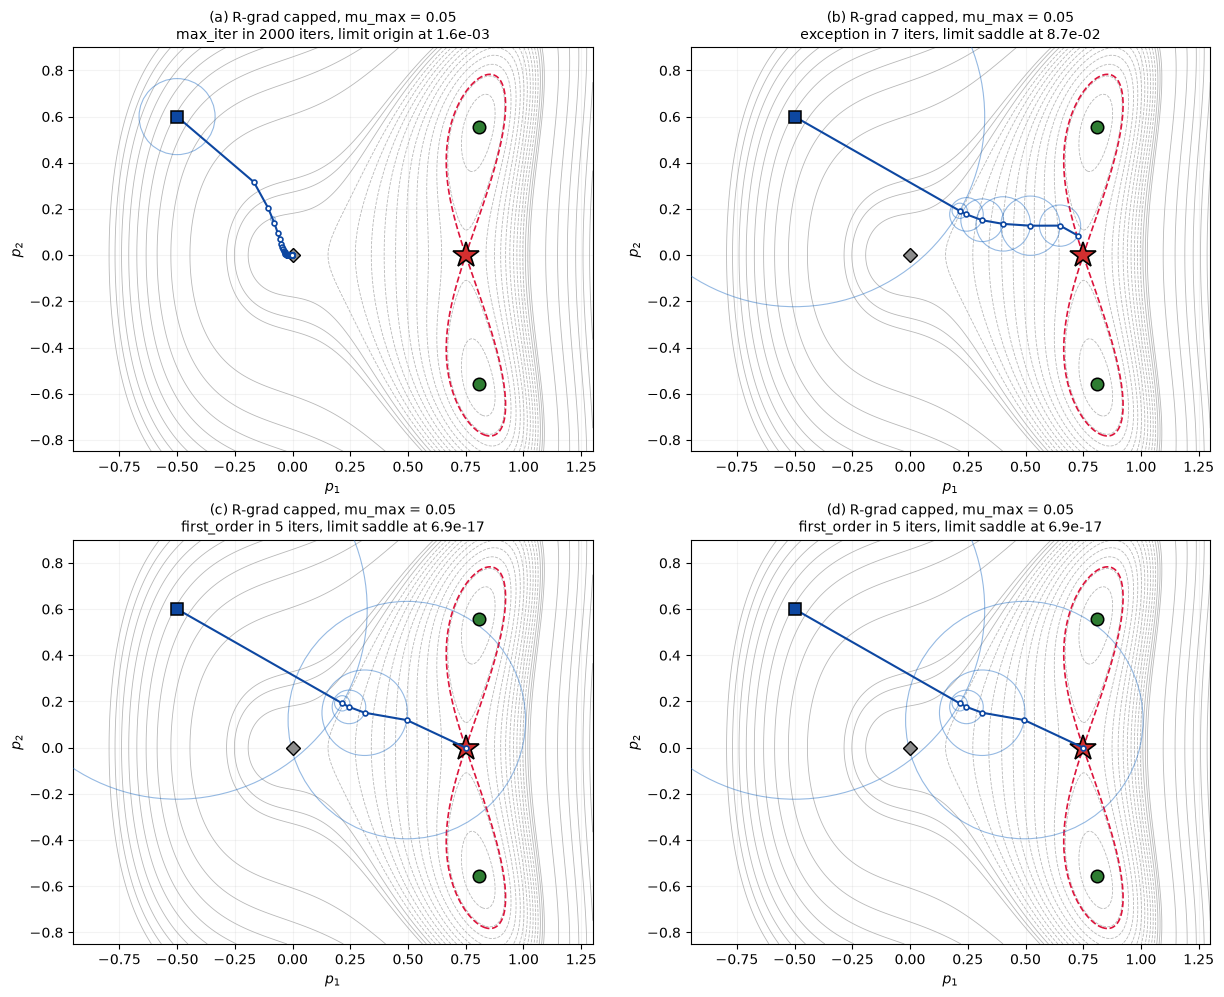

In [ ]:
"""
    four_regimes(specs; savepath) -> figure

One panel per entry of `specs`, which is `(label, rule)`. Same axes, same
contours, the trust region of every accepted step, and the four critical points.
Each panel runs `solve_path`, so the iterates come from the solver's callback.
"""
function four_regimes(specs; savepath = nothing)
    xg = range(-0.95, 1.30, length = 420)
    yg = range(-0.85, 0.90, length = 380)
    Xg = [xi for yi in yg, xi in xg]
    Yg = [yi for yi in yg, xi in xg]
    Zg = @. Xg^4 - Xg^3 + (0.25 - Xg/2)*Yg^2 + Yg^4/4
    lv = sort(vcat(collect(range(-0.13, 0.02, length = 14)),
                   collect(range(0.03, 0.9, length = 10))))

    fig = PyPlot.figure(figsize = (12.5, 10.0))
    for (i, (label, rule)) in enumerate(specs)
        st, xs = solve_path(rule = rule, model = SPDTarget(target = SADDLE),
                            subsolver = SteihaugCG(), kmax = KMAX, tol = TOL)
        ss = st.solver_specific
        Δv = ss[:delta_trajectory]; cv = ss[:accepted_trajectory]
        P  = reduce(hcat, xs)
        nc = nearest_crit(st.solution)

        ax = fig.add_subplot(2, 2, i)
        ax.contour(Xg, Yg, Zg, levels = lv, colors = "0.72", linewidths = 0.6, zorder = 1)
        ax.contour(Xg, Yg, Zg, levels = [f(SADDLE)], colors = "crimson",
                   linewidths = 1.2, linestyles = "--", zorder = 2)
        # One circle per accepted step, thinned so a two thousand iteration run
        # does not paint two thousand patches on one panel.
        acc = [j for j in 1:length(cv) if cv[j]]
        st_r = max(1, length(acc) ÷ 120)
        for j in acc[1:st_r:end]
            ax.add_patch(PyPlot.matplotlib.patches.Circle((P[1, j], P[2, j]), Δv[j],
                         fill = false, ec = "#1565c0", lw = 0.8, alpha = 0.45, zorder = 3))
        end
        ax.plot([MINP[1], MINM[1]], [MINP[2], MINM[2]], "o", ms = 9, mfc = "#2e7d32",
                mec = "k", mew = 1.1, zorder = 6)
        ax.plot([ORIGIN[1]], [ORIGIN[2]], "D", ms = 7, mfc = "0.55", mec = "k",
                mew = 1.0, zorder = 6)
        ax.plot([SADDLE[1]], [SADDLE[2]], "*", ms = 19, mfc = "#d32f2f", mec = "k",
                mew = 1.2, zorder = 7)
        stride = max(1, size(P, 2) ÷ 300)
        idx = unique(vcat(1:stride:size(P, 2), size(P, 2)))
        ax.plot(P[1, idx], P[2, idx], "-o", color = "#0d47a1", ms = 3.5, lw = 1.5,
                mfc = "white", mec = "#0d47a1", mew = 1.2, zorder = 8)
        ax.plot([P[1, 1]], [P[2, 1]], "s", ms = 8, mfc = "#0d47a1", mec = "k",
                mew = 1.1, zorder = 9)
        ax.set_title(@sprintf("(%s) %s\n%s in %d iters, limit %s at %.1e",
                              "abcd"[i], label, string(st.status), st.iter,
                              nc.name, nc.dist), fontsize = 10)
        ax.set_xlabel("\$p_1\$"); ax.set_ylabel("\$p_2\$")
        ax.set_xlim(-0.95, 1.30); ax.set_ylim(-0.85, 0.90)
        ax.set_aspect("equal"); ax.grid(alpha = 0.14)
    end
    PyPlot.tight_layout()
    savepath === nothing || PyPlot.savefig(savepath, dpi = 165, bbox_inches = "tight")
    return fig
end

FOUR = [("R-grad capped, mu_max = 0.1", mk_cap(0.1)),
        ("R-grad capped, mu_max = 0.5", mk_cap(0.5)),
        ("R-grad capped, mu_max = 2.0", mk_cap(2.0)),
        ("R-grad capped, mu_max = 128.0", mk_cap(128.0)),]
fig4 = four_regimes(FOUR;
                    savepath = joinpath(@__DIR__, "four_regimes_rgradcapped.pdf"))

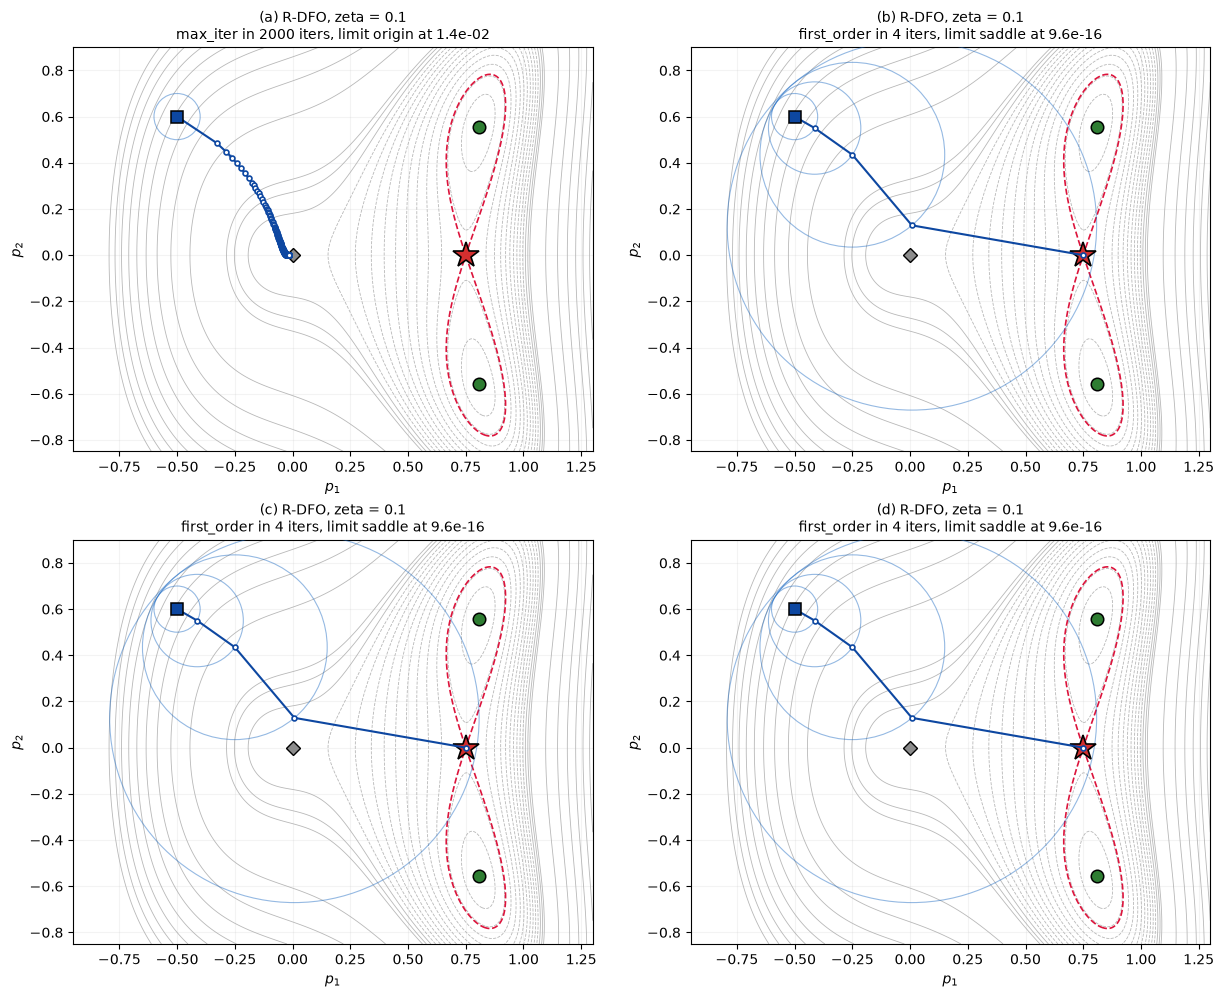

In [ ]:
"""
    four_regimes(specs; savepath) -> figure

One panel per entry of `specs`, which is `(label, rule)`. Same axes, same
contours, the trust region of every accepted step, and the four critical points.
Each panel runs `solve_path`, so the iterates come from the solver's callback.
"""
function four_regimes(specs; savepath = nothing)
    xg = range(-0.95, 1.30, length = 420)
    yg = range(-0.85, 0.90, length = 380)
    Xg = [xi for yi in yg, xi in xg]
    Yg = [yi for yi in yg, xi in xg]
    Zg = @. Xg^4 - Xg^3 + (0.25 - Xg/2)*Yg^2 + Yg^4/4
    lv = sort(vcat(collect(range(-0.13, 0.02, length = 14)),
                   collect(range(0.03, 0.9, length = 10))))

    fig = PyPlot.figure(figsize = (12.5, 10.0))
    for (i, (label, rule)) in enumerate(specs)
        st, xs = solve_path(rule = rule, model = SPDTarget(target = SADDLE),  Δ0=0.1, 
                            subsolver = SteihaugCG(), kmax = KMAX, tol = TOL)
        ss = st.solver_specific
        Δv = ss[:delta_trajectory]; cv = ss[:accepted_trajectory]
        P  = reduce(hcat, xs)
        nc = nearest_crit(st.solution)

        ax = fig.add_subplot(2, 2, i)
        ax.contour(Xg, Yg, Zg, levels = lv, colors = "0.72", linewidths = 0.6, zorder = 1)
        ax.contour(Xg, Yg, Zg, levels = [f(SADDLE)], colors = "crimson",
                   linewidths = 1.2, linestyles = "--", zorder = 2)
        # One circle per accepted step, thinned so a two thousand iteration run
        # does not paint two thousand patches on one panel.
        acc = [j for j in 1:length(cv) if cv[j]]
        st_r = max(1, length(acc) ÷ 120)
        for j in acc[1:st_r:end]
            ax.add_patch(PyPlot.matplotlib.patches.Circle((P[1, j], P[2, j]), Δv[j],
                         fill = false, ec = "#1565c0", lw = 0.8, alpha = 0.45, zorder = 3))
        end
        ax.plot([MINP[1], MINM[1]], [MINP[2], MINM[2]], "o", ms = 9, mfc = "#2e7d32",
                mec = "k", mew = 1.1, zorder = 6)
        ax.plot([ORIGIN[1]], [ORIGIN[2]], "D", ms = 7, mfc = "0.55", mec = "k",
                mew = 1.0, zorder = 6)
        ax.plot([SADDLE[1]], [SADDLE[2]], "*", ms = 19, mfc = "#d32f2f", mec = "k",
                mew = 1.2, zorder = 7)
        stride = max(1, size(P, 2) ÷ 300)
        idx = unique(vcat(1:stride:size(P, 2), size(P, 2)))
        ax.plot(P[1, idx], P[2, idx], "-o", color = "#0d47a1", ms = 3.5, lw = 1.5,
                mfc = "white", mec = "#0d47a1", mew = 1.2, zorder = 8)
        ax.plot([P[1, 1]], [P[2, 1]], "s", ms = 8, mfc = "#0d47a1", mec = "k",
                mew = 1.1, zorder = 9)
        ax.set_title(@sprintf("(%s) %s\n%s in %d iters, limit %s at %.1e",
                              "abcd"[i], label, string(st.status), st.iter,
                              nc.name, nc.dist), fontsize = 10)
        ax.set_xlabel("\$p_1\$"); ax.set_ylabel("\$p_2\$")
        ax.set_xlim(-0.95, 1.30); ax.set_ylim(-0.85, 0.90)
        ax.set_aspect("equal"); ax.grid(alpha = 0.14)
    end
    PyPlot.tight_layout()
    savepath === nothing || PyPlot.savefig(savepath, dpi = 165, bbox_inches = "tight")
    return fig
end

FOUR = [("R-DFO, zeta = 0.01",            mk_dfo(0.01)),
        ("R-DFO, zeta = 1.0",            mk_dfo(1.0)),
        ("R-DFO, zeta = 10.0",            mk_dfo(10.0)),
        ("R-DFO, zeta = 100.0",            mk_dfo(100.0))]
fig4 = four_regimes(FOUR;
                    savepath = joinpath(@__DIR__, "four_regimes_dfo.pdf"))


B. second-order R-grad, exact Hessian, subsolver unchanged
ExactHessian + SecondOrder + SteihaugCG : second_order in 16 iters -> origin


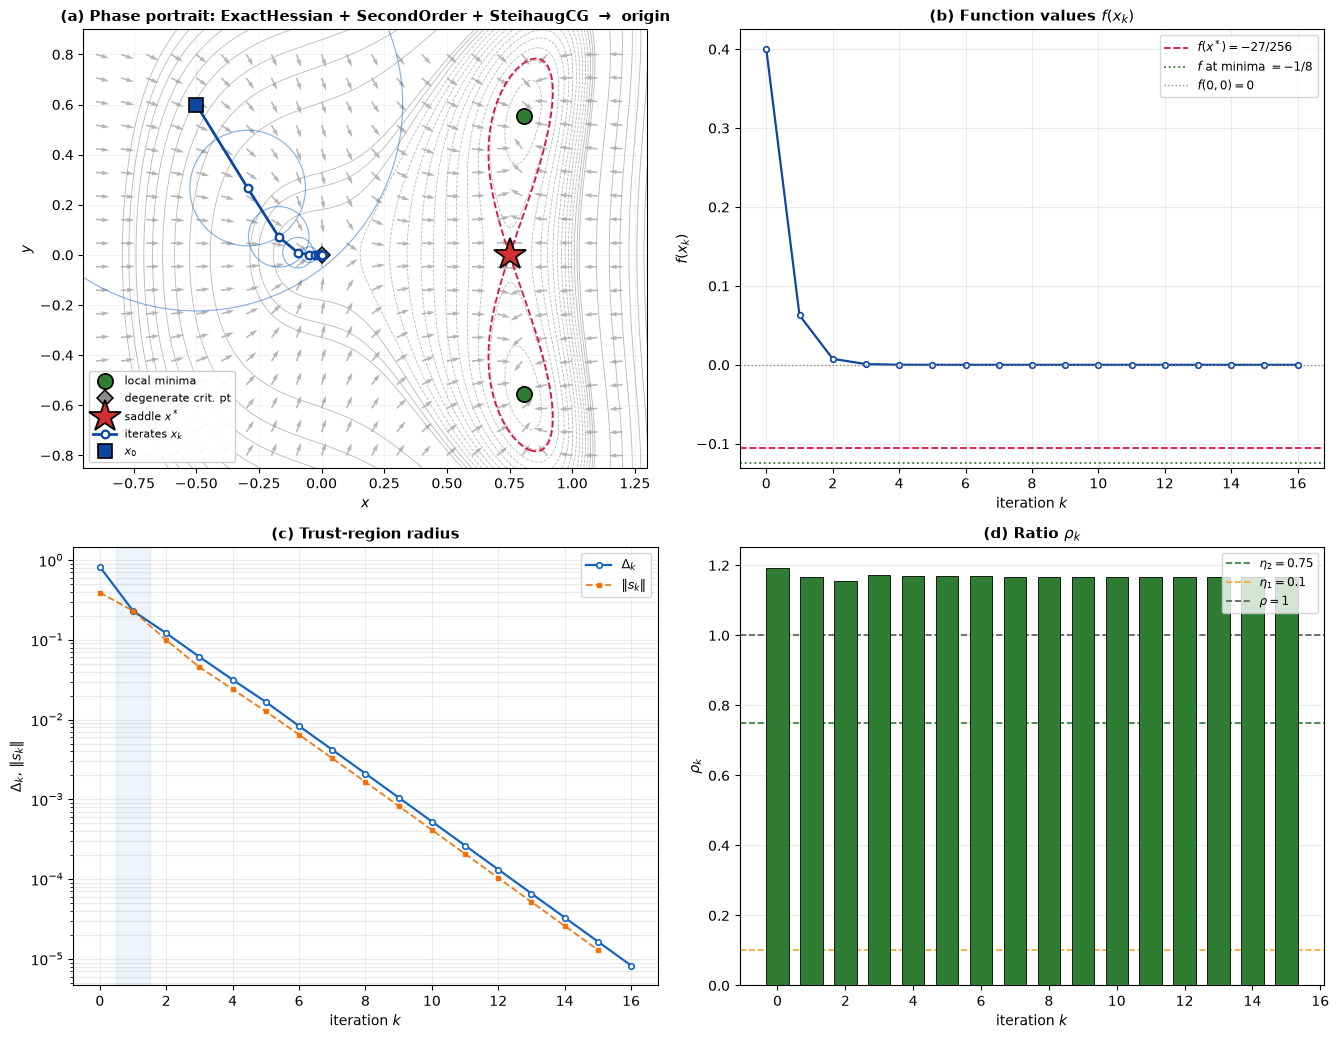

In [16]:
println()
println("="^96)
println("B. second-order R-grad, exact Hessian, subsolver unchanged")
println("="^96)
fig_b = diagnose(rule = RGradTau(γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0, Δmin = 0.0),
                 model = ExactHessian(), subsolver = SteihaugCG(),
                 kmax = KMAX, tol = TOL, tol_H = 1e-6,
                 savepath = joinpath(SADDLEDIR, "B_rgradtau_exact_cg.png"))


C. the same with EigenPoint, the notebook's convention when tol_H > 0
ExactHessian + SecondOrder + EigenPoint : second_order in 13 iters -> min+


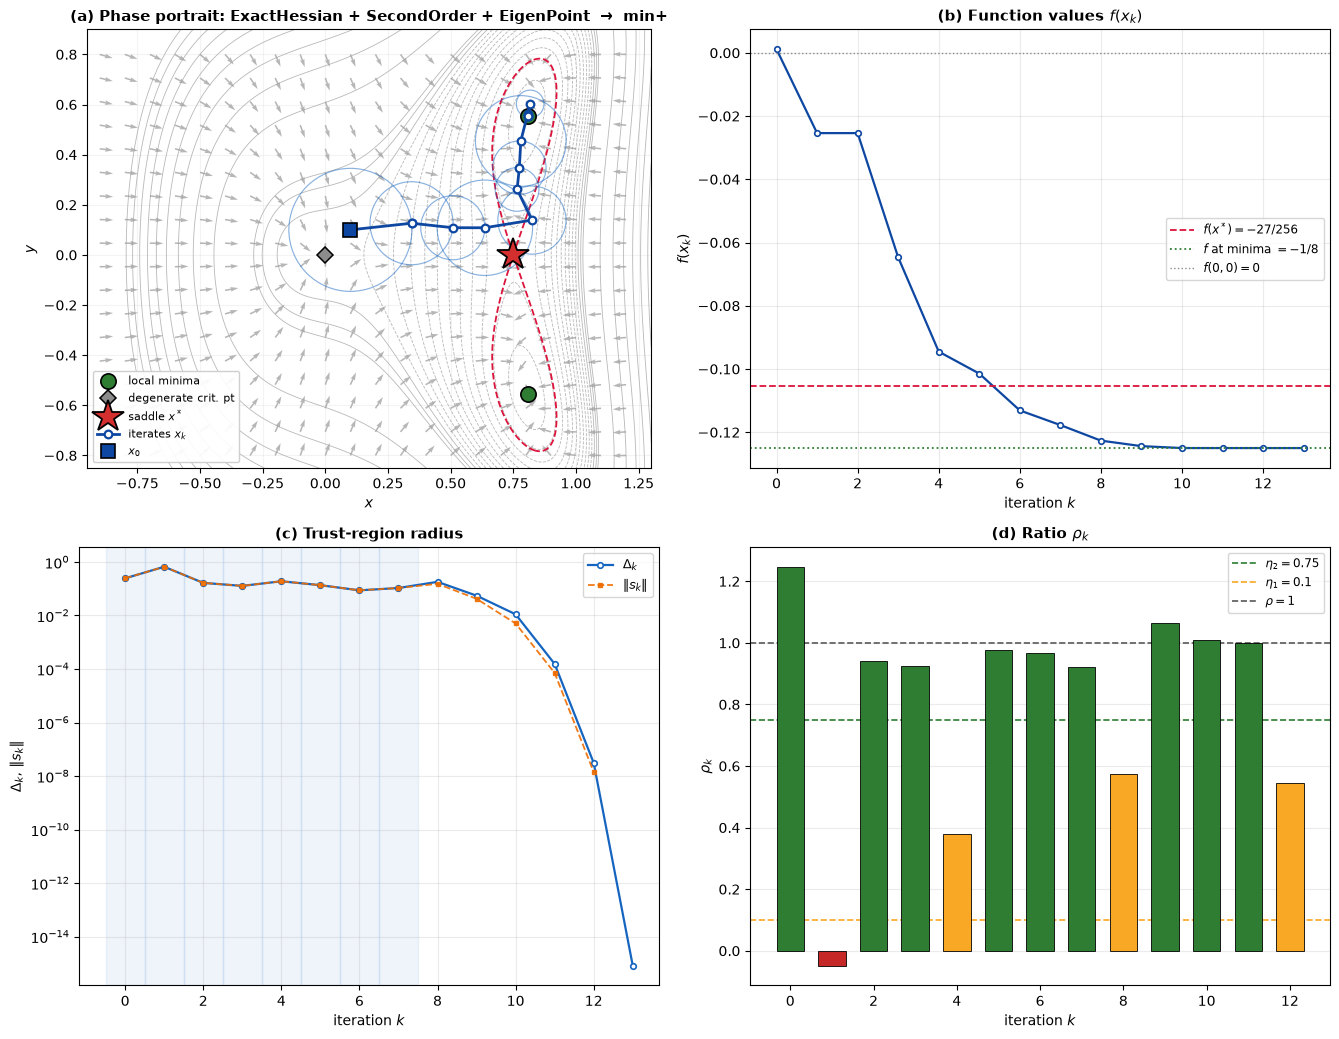

In [23]:
println()
println("="^96)
println("C. the same with EigenPoint, the notebook's convention when tol_H > 0")
println("="^96)
fig_c = diagnose(rule = RGradTau(γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0, Δmin = 0.0),
                 model = ExactHessian(), subsolver = EigenPoint(SteihaugCG()),
                 kmax = KMAX, tol = TOL, tol_H = 1e-6,  x0 =[0.1 , 0.1],
                 savepath = joinpath(SADDLEDIR, "C_rgradtau_exact_eigenpoint.png"))


D. second-order rule but tol_H left at its default of -1
ExactHessian + SecondOrder + SteihaugCG : first_order in 7 iters -> min+


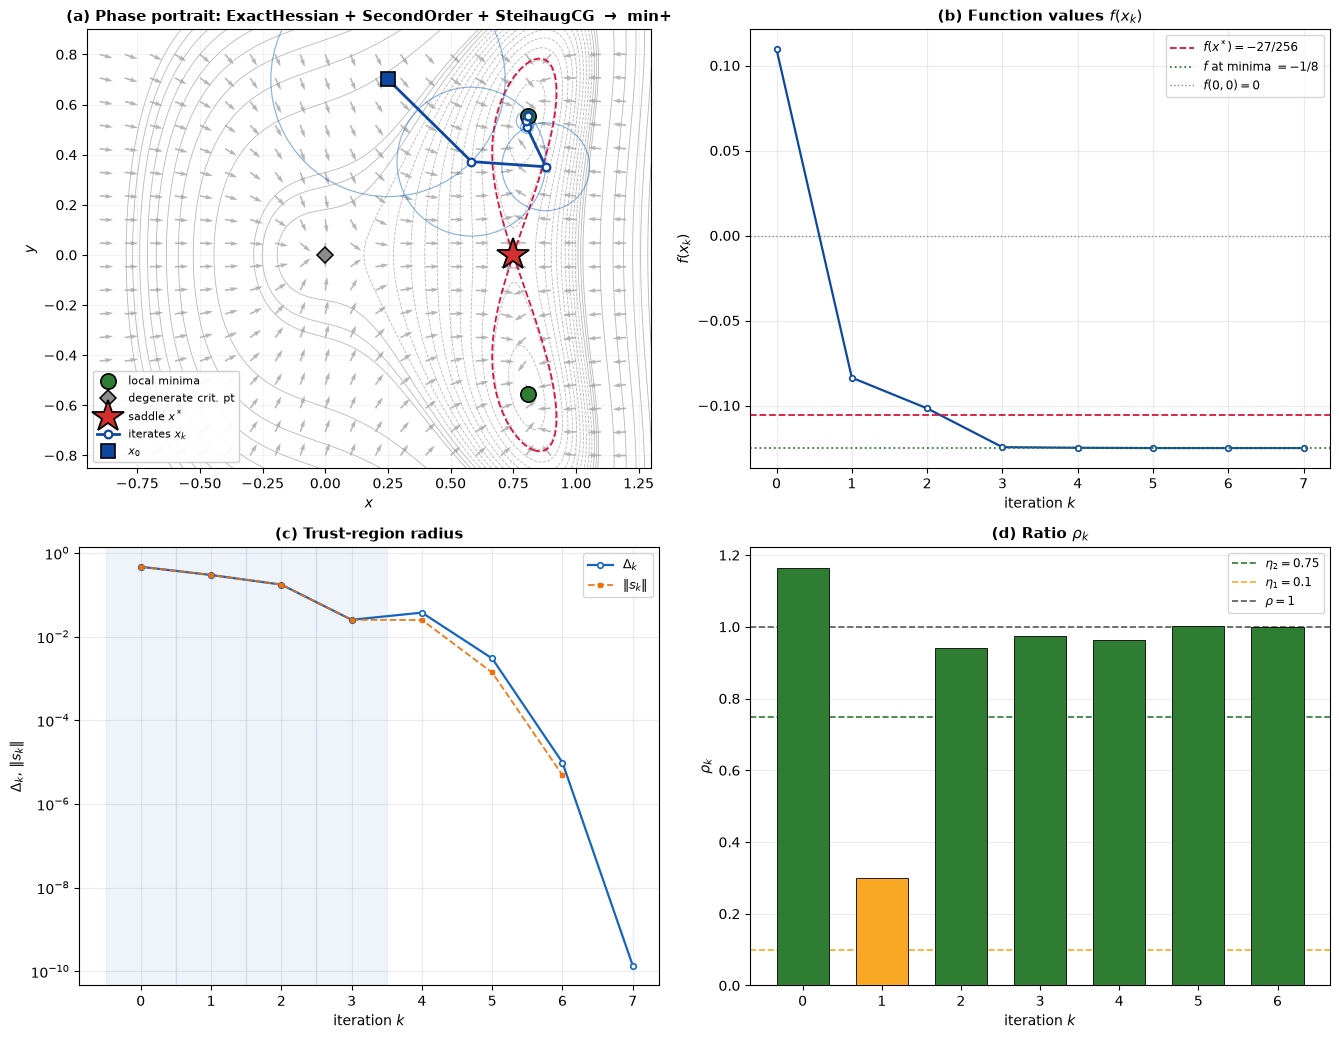

In [37]:
println()
println("="^96)
println("D. second-order rule but tol_H left at its default of -1")
println("="^96)
fig_d = diagnose(rule = SecondOrder(RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0, μ_max = 128, Δmin = 0.0)),
                 model = ExactHessian(), subsolver = SteihaugCG(),
                 kmax = KMAX, tol = TOL, x0 =[0.25 , 0.7],
                 savepath = joinpath(SADDLEDIR, "D_rgradtau_no_tolH.png"))

In [25]:
RGradTau(γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0, Δmin = 0.0)

SecondOrder — radius anchored to τ = max{‖g‖, −λ_min(B)}
RGrad:
  γ1         0.25
  γ2         0.5
  γ3         2.0
  μ          0.5
  μ0         0.5
  half_test  true
  Δmin       0.0
  Δmax       Inf
  (asymptotic regime: vanishing)


## 2. Two runs in detail

`diagnose` of the shared file draws the phase portrait with the trust regions,
the function values, the radius against the step length, and the ratio. Two rules
far apart in the roster are shown, one whose radius ignores the criticality
measure and one whose radius is proportional to it.

SPDTarget + RDelta + SteihaugCG : first_order in 2 iters -> saddle


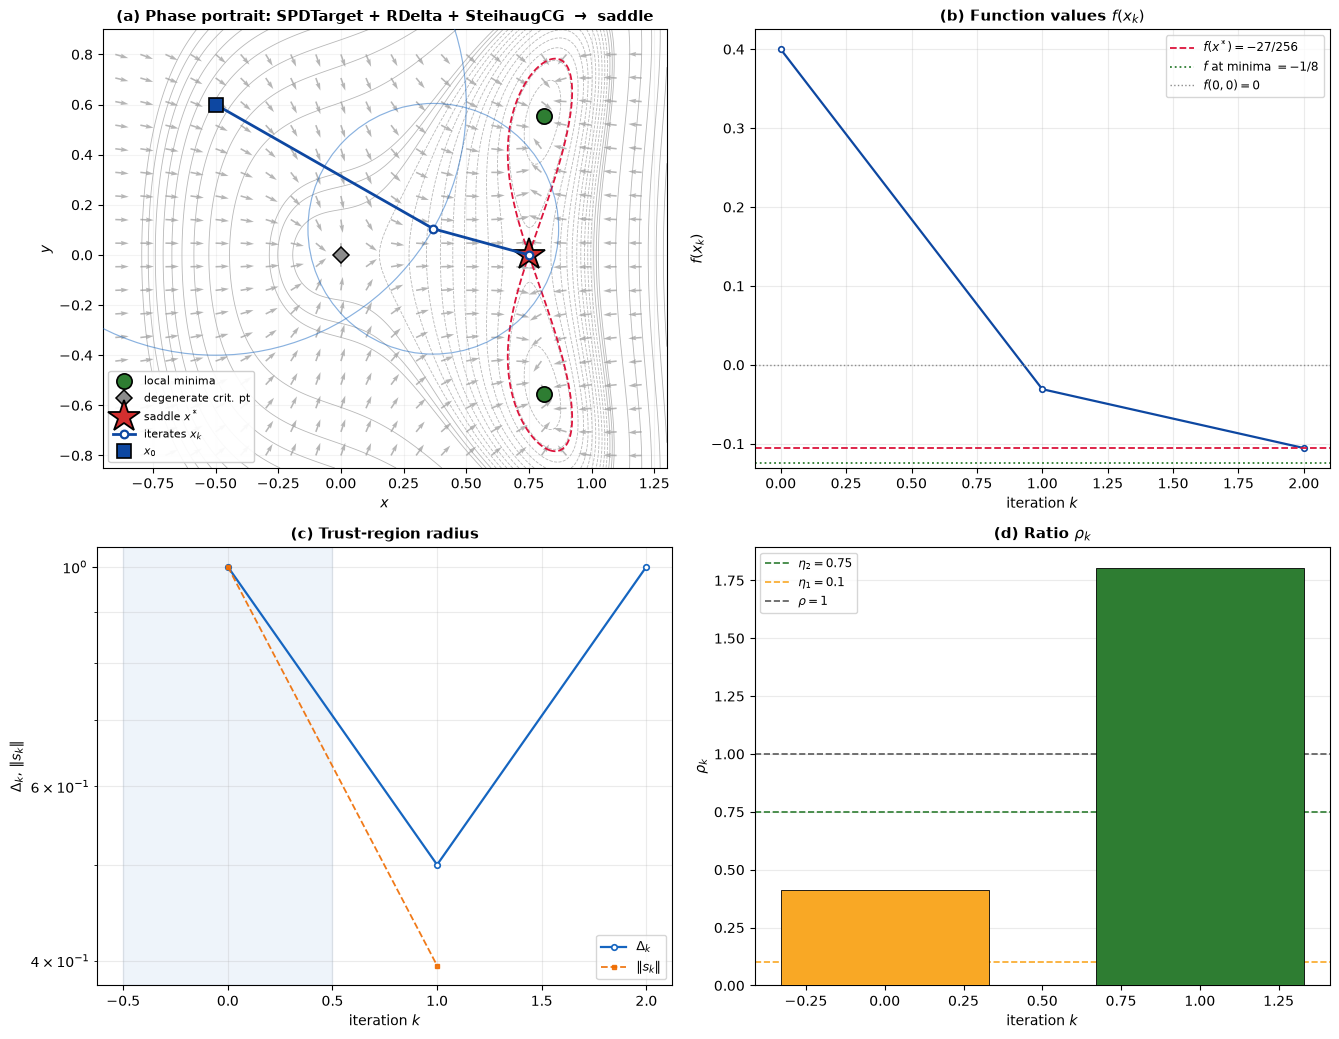

In [7]:
fig_delta = diagnose(rule = RDelta(γ1 = G1, γ2 = G2, γ3 = G3, Δmin = 0.0),
                     model = SPDTarget(target = SADDLE), subsolver = SteihaugCG(),
                     kmax = KMAX, tol = TOL,
                     savepath = joinpath(SADDLEDIR, "spd_target_diag_rdelta.png"))

SPDTarget + RGradCapped + SteihaugCG : max_iter in 2000 iters -> other


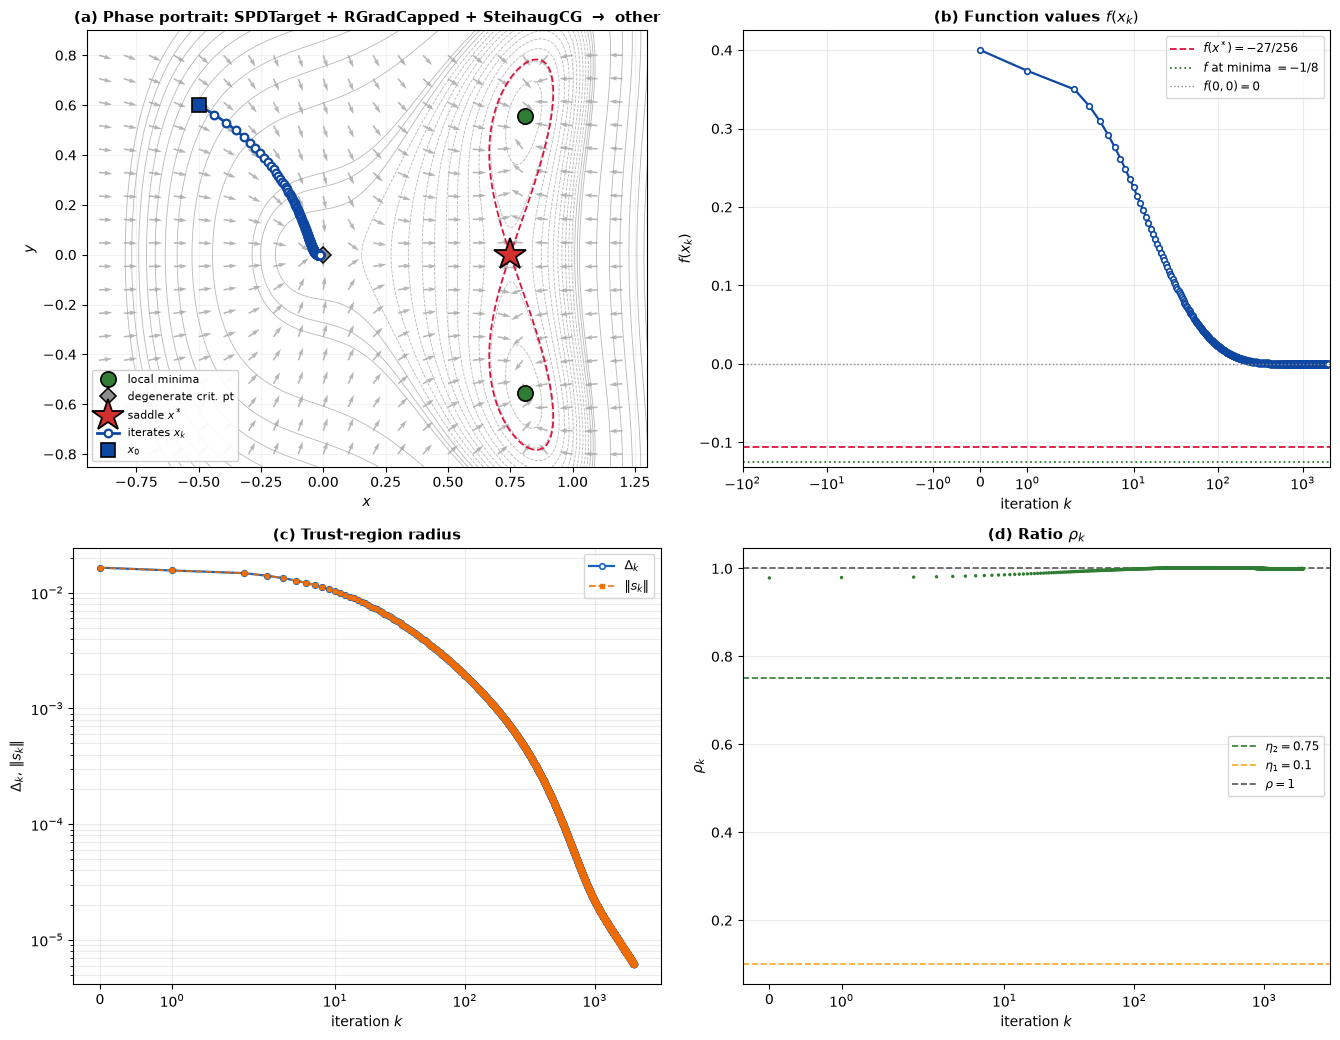

In [8]:
fig_grad = diagnose(rule = RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3, μ = 0.1, μ_max= 0.01, Δmin = 0.0),
                    model = SPDTarget(target = SADDLE), subsolver = SteihaugCG(),
                    kmax = KMAX, tol = TOL,
                    savepath = joinpath(SADDLEDIR, "spd_target_diag_rgrad_capped_small.png"))

SPDTarget + RGrad + SteihaugCG : first_order in 5 iters -> saddle


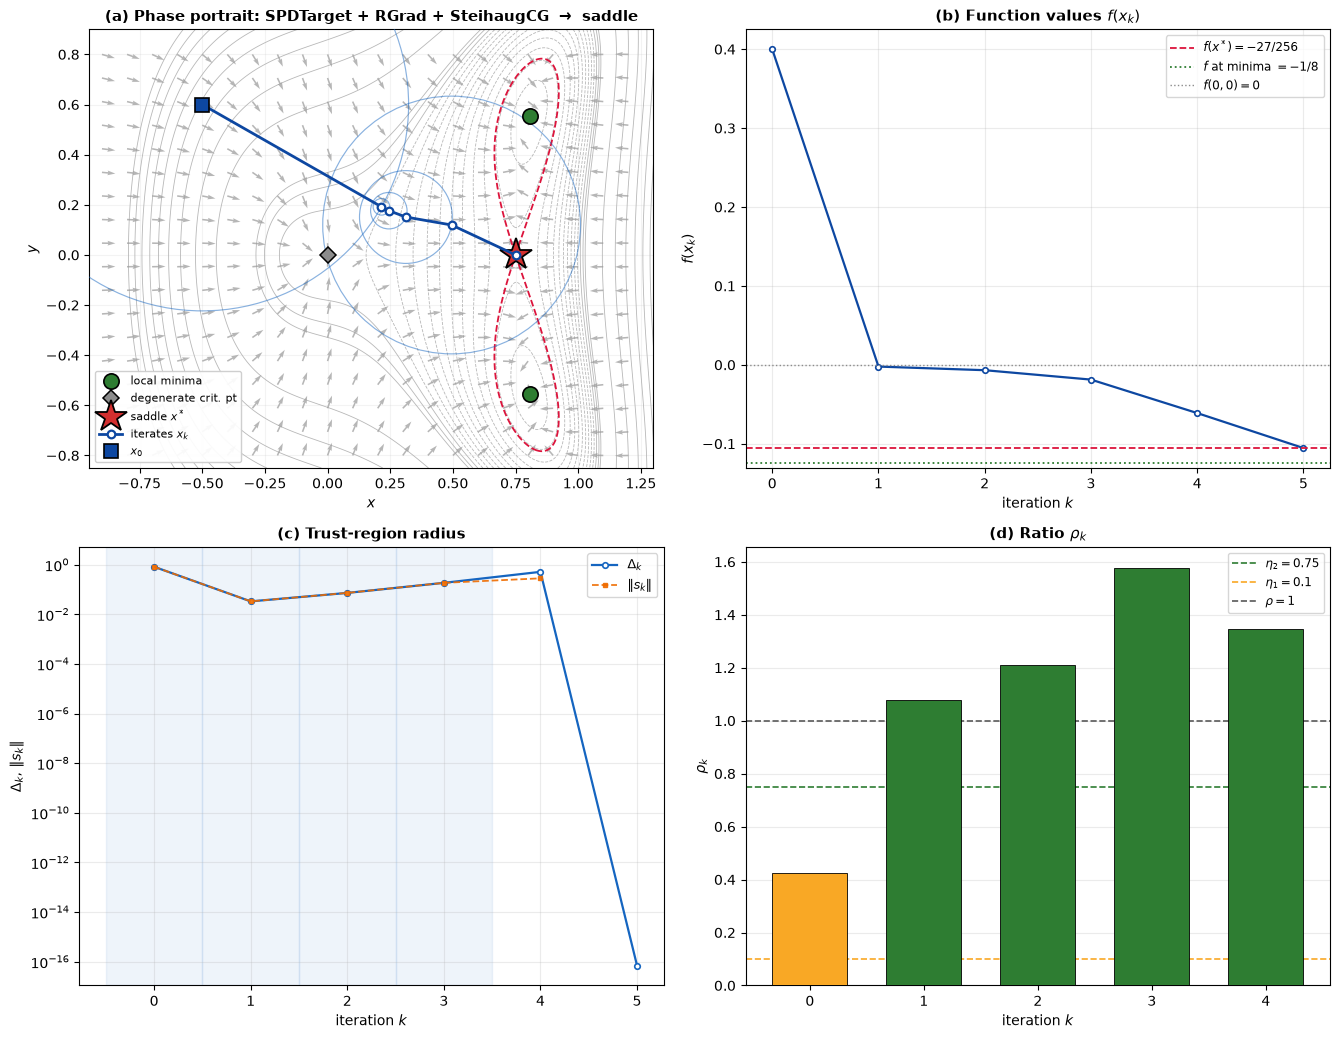

In [9]:
fig_grad = diagnose(rule = RGrad(γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0, Δmin = 0.0),
                    model = SPDTarget(target = SADDLE), subsolver = SteihaugCG(),
                    kmax = KMAX, tol = TOL,
                    savepath = joinpath(SADDLEDIR, "spd_target_diag_rgrad.png"))

## 3. What the second-order test does at a strict saddle

With the test off, the solver reports a first-order status at $(0.75, 0)$. That
is correct for the criterion it was given. $\|g\| \leq \texttt{tol}$ holds and
nothing was asked about curvature.

The prediction to test is that with $\texttt{tol\_H} > 0$ the run refuses. The
test is on $\lambda_{\min}(B_k)$, the **model** Hessian, and `SPDTarget` is
positive definite by construction, so the run below is the case where the model
cannot see the curvature that is there.

The same point is then run under `ExactHessian`, where $\lambda_{\min} = -1/4$ is
visible, so the rows separate the point from the model.

Table 3 adds the subsolver, because refusing to stop and being able to move are
two different things. At the saddle the gradient is zero, and `ExactMS` returns
the zero step whenever it is, by its own guard. `EigenPoint` takes the
eigenpoint instead.

In [10]:
println("The two Hessians at the saddle\n")
@printf("true  lambda_min(hess(saddle))            = %+.8f\n",
        eigvals(Symmetric(hess(SADDLE)))[1])
let m = SPDTarget(target = SADDLE), nlp = make_nlp(X0_DEFAULT)
    reset_model!(m, 2)
    B = Symmetric(Matrix(dense_hessian(m, nlp, X0_DEFAULT)))
    @printf("model lambda_min(SPDTarget at x0)         = %+.8f\n", eigvals(B)[1])
end
@printf("reports_negative_curvature(SPDTarget())   = %s\n",
        reports_negative_curvature(SPDTarget(target = SADDLE)))
@printf("reports_negative_curvature(ExactHessian()) = %s\n",
        reports_negative_curvature(ExactHessian()))

The two Hessians at the saddle

true  lambda_min(hess(saddle))            = -0.25000000
model lambda_min(SPDTarget at x0)         = +0.97249396
reports_negative_curvature(SPDTarget())   = false
reports_negative_curvature(ExactHessian()) = true


In [11]:
println("\n", "="^124)
println("TABLE 2. The same rules with the second-order test ON, tol_H = 1e-6, ",
        "still over SPDTarget.")
println("="^124)
SPD_ON = [spd_row(nm, mk; tol_H = 1e-6, subsolver = () -> EigenPoint(SteihaugCG()))
          for (nm, mk) in ALL_RULES]
spd_table(SPD_ON)

let ok = [r for r in SPD_ON if r.ok],
    cert = [r for r in SPD_ON if r.ok && r.status === :second_order],
    sad  = [r for r in SPD_ON if r.ok && r.limit == "saddle"]
    println()
    @printf("runs that certified :second_order         : %d of %d\n", length(cert), length(ok))
    @printf("of those, how many stopped at the saddle  : %d\n",
            count(r -> r.limit == "saddle", cert))
    @printf("runs whose limit is the saddle            : %d of %d\n", length(sad), length(ok))
    println()
    if !isempty(cert) && count(r -> r.limit == "saddle", cert) > 0
        println("The prediction FAILS over this model, and the reason is the model.")
        println("SPDTarget is positive definite by construction, so lambda_min(B) > 0 at")
        println("every iterate, so the test certifies a point whose true curvature is")
        println("-1/4. The certificate is a statement about B and not about f.")
    else
        println("The prediction HOLDS over this model: no run certified the saddle.")
    end
end


TABLE 2. The same rules with the second-order test ON, tol_H = 1e-6, still over SPDTarget.


┌ Warning: τ ≡ ‖g‖: this model is positive (semi)definite by construction, so λ_min(B) ≥ 0 always and the second-order machinery is a no-op. A :second_order status from this run certifies nothing about ∇²f. Use ExactHessian or SR1Model when the second-order question is the question.
│   model = SPDTarget
└ @ TrustRegionRadius c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\src\Trust-region\common.jl:322


rule                          status   iter | limit           dist dist saddle         |g| |     lam true  |lam+0.25|  tail act
----------------------------------------------------------------------------------------------------------------------------
RDelta                  second_order      2 | saddle     2.776e-17   2.776e-17   6.939e-18 |  -0.25000000    0.00e+00    0.0000
RStep                   second_order      2 | saddle     2.776e-17   2.776e-17   6.939e-18 |  -0.25000000    0.00e+00    0.0000
RDeltaStep              second_order      2 | saddle     2.776e-17   2.776e-17   6.939e-18 |  -0.25000000    0.00e+00    0.0000
RDFO                    second_order      2 | saddle     2.776e-17   2.776e-17   6.939e-18 |  -0.25000000    0.00e+00    0.0000
RGrad                   second_order      5 | saddle     6.939e-17   6.939e-17   1.735e-17 |  -0.25000000    0.00e+00    0.0000
RGradCapped             second_order      5 | saddle     6.939e-17   6.939e-17   1.735e-17 |  -0.25000000  

In [12]:
# The same point under a model that can see the curvature.
println("\n", "="^122)
println("TABLE 3. Started ON the saddle, tol_H = 1e-6, by model and subsolver.")
println("="^122)
@printf("%-14s %-12s %14s %6s | %12s %12s %12s | %-8s %10s\n",
        "model", "subsolver", "status", "iter", "|g| at end", "lam model",
        "lam true", "limit", "dist")
println("-"^122)
for (mnm, mkm) in (("SPDTarget",    () -> SPDTarget(target = SADDLE)),
                   ("ExactHessian", () -> ExactHessian())),
    (snm, mks) in (("ExactMS",    () -> ExactMS()),
                   ("EigenPoint", () -> EigenPoint(SteihaugCG())))
    st = run_cfg(rule = RDelta(γ1 = G1, γ2 = G2, γ3 = G3, Δmin = 0.0),
                 model = mkm(), subsolver = mks(), x0 = SADDLE, tol_H = 1e-6)
    λm = get(st.solver_specific, :lambda_min_trajectory, Float64[])
    nc = nearest_crit(st.solution)
    @printf("%-14s %-12s %14s %6d | %12.3e %12.8f %12.8f | %-8s %10.2e\n",
            mnm, snm, string(st.status), st.iter, Float64(st.dual_feas),
            isempty(λm) ? NaN : λm[end],
            eigvals(Symmetric(hess(st.solution)))[1], nc.name, nc.dist)
end

println()
println("At the saddle the gradient is zero. `ExactMS` returns the zero step there,")
println("by its own guard `norm(g) == 0 || Delta <= 0`, so a run started on the saddle")
println("cannot move under it however much negative curvature the model reports, and")
println("it stalls. `EigenPoint` computes the eigenpoint and compares model decreases,")
println("so it moves. Whether the test refuses is the model. Whether the run can act")
println("on the refusal is the subsolver. The two are independent and the table")
println("separates them.")


TABLE 3. Started ON the saddle, tol_H = 1e-6, by model and subsolver.
model          subsolver            status   iter |   |g| at end    lam model     lam true | limit          dist
--------------------------------------------------------------------------------------------------------------------------
SPDTarget      ExactMS        second_order      0 |    0.000e+00   1.00000000  -0.25000000 | saddle     0.00e+00
SPDTarget      EigenPoint     second_order      0 |    0.000e+00   1.00000000  -0.25000000 | saddle     0.00e+00
ExactHessian   ExactMS             stalled      1 |    0.000e+00  -0.25000000  -0.25000000 | saddle     0.00e+00
ExactHessian   EigenPoint     second_order      9 |    5.239e-15   0.49468921   0.49468921 | min-       9.41e-15

At the saddle the gradient is zero. `ExactMS` returns the zero step there,
by its own guard `norm(g) == 0 || Delta <= 0`, so a run started on the saddle
cannot move under it however much negative curvature the model reports, and
it stalls. 

## 4. The two failures side by side

The origin of the first notebook and the saddle of this one fail the
second-order test in different ways, and the pair says what the test detects.

At the origin the point has no negative curvature. $\lambda_{\min} = 0$, so
$0 \geq -\texttt{tol\_H}$ for every positive tolerance and the test certifies. No
model and no subsolver changes that, because there is nothing to see.

At the saddle the point has negative curvature and the model does not report it.
$\lambda_{\min}(\nabla^2 f) = -1/4$ while $\lambda_{\min}(B) > 0$, and the test
certifies for that reason instead.

The test detects negative curvature **of the model**, at a point that has some.
Both failures are outside that description, and each is outside it in its own
way.

In [13]:
println("\n", "="^96)
println("TABLE 4. The two failures.")
println("="^96)
@printf("%-10s %12s %14s %14s %16s\n",
        "point", "|g|", "lam true", "lam model", "test at 1e-6")
println("-"^96)
for (nm, p, mnm, mkm) in (("origin", ORIGIN, "ExactHessian", () -> ExactHessian()),
                          ("saddle", SADDLE, "ExactHessian", () -> ExactHessian()),
                          ("saddle", SADDLE, "SPDTarget",    () -> SPDTarget(target = SADDLE)))
    gn = norm(grad(p))
    λt = eigvals(Symmetric(hess(p)))[1]
    m  = mkm(); reset_model!(m, 2); nlp = make_nlp(p)
    λb = try
        eigvals(Symmetric(Matrix(dense_hessian(m, nlp, p))))[1]
    catch
        NaN
    end
    @printf("%-10s %12.2e %14.8f %14.8f %16s   (%s)\n",
            nm, gn, λt, λb, string(second_order_status(gn, λb, TOL, 1e-6)), mnm)
end


TABLE 4. The two failures.
point               |g|       lam true      lam model     test at 1e-6
------------------------------------------------------------------------------------------------
origin         0.00e+00    -0.00000000     0.00000000     second_order   (ExactHessian)
saddle         0.00e+00    -0.25000000    -0.25000000      first_order   (ExactHessian)
saddle         0.00e+00    -0.25000000     1.00000000     second_order   (SPDTarget)


In [14]:
println("\nDONE. Figures written to ", SADDLEDIR)


DONE. Figures written to c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks\FINAL\SPD
